In [ ]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from astropy.table import Table, join, hstack
from astropy.io import fits
import tomllib
from astropy.wcs import WCS
from scipy.spatial import cKDTree
from scipy.stats import kde
import glob
import os
from astropy.visualization import ImageNormalize, PercentileInterval

In [2]:
# Load the tables from the catalog filder
def load_catalogs(gal, band, cat_dir, ext=""):
    catalog = Table.read(f"{cat_dir}{gal}_jwst_{band.upper()}_cat{ext}.fits")
    return catalog



def get_path_to_file(wdir, version, project, galaxy, ptype):
     """Get the path to the data file based on the version, project, galaxy, product type, and filter.
     Args:
          version: version of the data (e.g., v4p1)
          project: JWST PID (e.g., 4793)
          galaxy: galaxy name 
          ptype: product type (e.g., images (for anchored), features, psfmatch, etc.)
          filter: filter name."""
     # TODO: Add functionality for files not in the release directory
     path = f"{wdir}{version}/{project}/release/{galaxy}/{ptype}/"

     # Check that the path exists
     if os.path.exists(path):
          print(f"Found file for {galaxy} {filter} in {path}")
     else:
          raise FileNotFoundError(f"No file found for {galaxy} {filter} in {path}. Please check the path and file naming conventions.")
     return path



def open_jwst(path, gal, dir, band, mosaic_ext="*anchor*.fits"):
     # Load the files
     print(f"Searching in {path} for {band} data, with extension: {mosaic_ext}")
     #     files = glob.glob(f"{path}/{gal.lower()}*{band.lower()}*{mosaic_ext}")
     files = glob.glob(path + f"*{band.lower()}*{mosaic_ext}*")
     print(f"Files found: {files}")

     # Sanity check that we are getting only one aligned mosaic
     if len(files) == 0:
          raise FileNotFoundError(f"No files found for {band} in {dir}{gal}")
     elif len(files) > 1:
          print(f"Warning: Multiple files found for {band} in {dir}{gal}. Using the first one: {files[0]}")

     # Initialize variables
     img_file = None
     # Open the file and use extensions to assign data and header
     with fits.open(files[0]) as hdul:
          img_file = hdul['SCI']
          img = img_file.data
          header = img_file.header
     return img,  header




def find_galaxy_center(img, header):
    """Find the center of the galaxy in pixel coordinates."""
    # Get the WCS from the header
    wcs = WCS(header)
    # Assume that the centre is the brightest region of the image
    # It needs to extend over a large enough area to avoid picking out a single bright star, 
    # but not so large that it includes the whole galaxy.
    # Use a large box size to find the brightest region
    box_size = (100, 100)  # in pixels
    # Check if box size is even. If it is, add one to each of the values
    if box_size[0] % 2 == 0:
        box_size = (box_size[0] + 1, box_size[1] + 1)
    # Smooth the image to the box size to find the brightest region
    from astropy.convolution import Gaussian2DKernel, convolve
    kernel = Gaussian2DKernel(x_stddev=box_size[0]/2, y_stddev=box_size[1]/2)
    smoothed_img = convolve(img, kernel)
    # Find the coordinates of the brightest region
    y_gc, x_gc = np.unravel_index(np.argmax(smoothed_img), smoothed_img.shape)
    return x_gc, y_gc




def sources_in_center(catalog, x_gc, y_gc,r=100):
    """Returns a boolean mask for sources that are within a radius r of the galaxy center."""
    # Compute the distance of each source from the galaxy center
    distances = np.sqrt((catalog['x_center'] - x_gc)**2 + (catalog['y_center'] - y_gc)**2)
    # Return a boolean mask for sources within radius r
    return distances < r


def match(
    catalog1, 
    catalog2, 
    npix=2, 
    keys=['catalog1', 'catalog2']):
    
    coords2 = np.array([catalog2['x_center'], catalog2['y_center']]).T
    coords1 = np.array([catalog1['x_center'], catalog1['y_center']]).T
    # Build a KD-tree for the first catalog
    tree = cKDTree(coords2)

    # Find matches within npix pixels
    # pixel_scale = 1#0.031
    max_distance = npix  # or e.g. 1.0 pixel if you want 1 pixel tolerance

    distances, indices = tree.query(coords1, k=1, distance_upper_bound=max_distance)

    # Create mask for valid matches (finite distance = match found)
    match_mask = np.isfinite(distances)

    # Build matched catalog
    matched1 = catalog1[match_mask]
    matched2 = catalog2[indices[match_mask]]

    # Optionally combine columns from both catalogs
    matched_cat = hstack([matched1, matched2], table_names=[keys[0],keys[1]])
    return matched_cat


def make_cmd(band1, band2, gal, cat_dir, col='tab:blue', ax=None, ext="", contours=False, center=False):
    if type(band1) == str or type(band2) == str:
        cat1 = load_catalogs(gal, band1, cat_dir, ext=ext)
        cat2 = load_catalogs(gal, band2, cat_dir, ext=ext)
    else:
        cat1 = band1
        cat2 = band2
    # Match the catalogs
    matched_cat = match(cat1, cat2, npix=2, keys=[band1, band2])

    # Get rid of any rown with NaN values in the relevant columns
    mask = np.isfinite(matched_cat[f'aperture_sum_abmag_{band1}']) & np.isfinite(matched_cat[f'aperture_sum_abmag_{band2}'])
    matched_cat = matched_cat[mask]

    # Get sources in the center of the galaxy
    if center:
        distances = np.sqrt((matched_cat['x_center_' + band1] - x_gc)**2 + (matched_cat['y_center_' + band1] - y_gc)**2)
        matched_cat = matched_cat[distances < 450]

    # Compute color and magnitude
    color = matched_cat[f'aperture_sum_abmag_{band1}'] - matched_cat[f'aperture_sum_abmag_{band2}']
    mag = matched_cat[f'aperture_sum_abmag_{band1}']
    # Plot the CMD
    if ax is None:
        print("ax is None, creating new figure and axis")
        fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.set_xlabel(f'{band1.upper()} - {band2.upper()}')
    ax.set_ylabel(f'{band1.upper()}')
    ax.invert_yaxis()
    if contours:
        # Add contours to the plot
        H, xedges, yedges = np.histogram2d(color, mag, bins=30)
        X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
        ax.contour(X, Y, H.T, levels=10, cmap=col)
    else:
        ax.scatter(color, mag, s=1, color=col)

    # # Get sources in center of the galaxy
    # print(matched_cat.colnames)
    # center_mask = sources_in_center(matched_cat, n=100)
    # ax.scatter(color[center_mask], mag[center_mask], s=10, color='red', label='Sources in center')
    # ax.legend()
    return color, mag

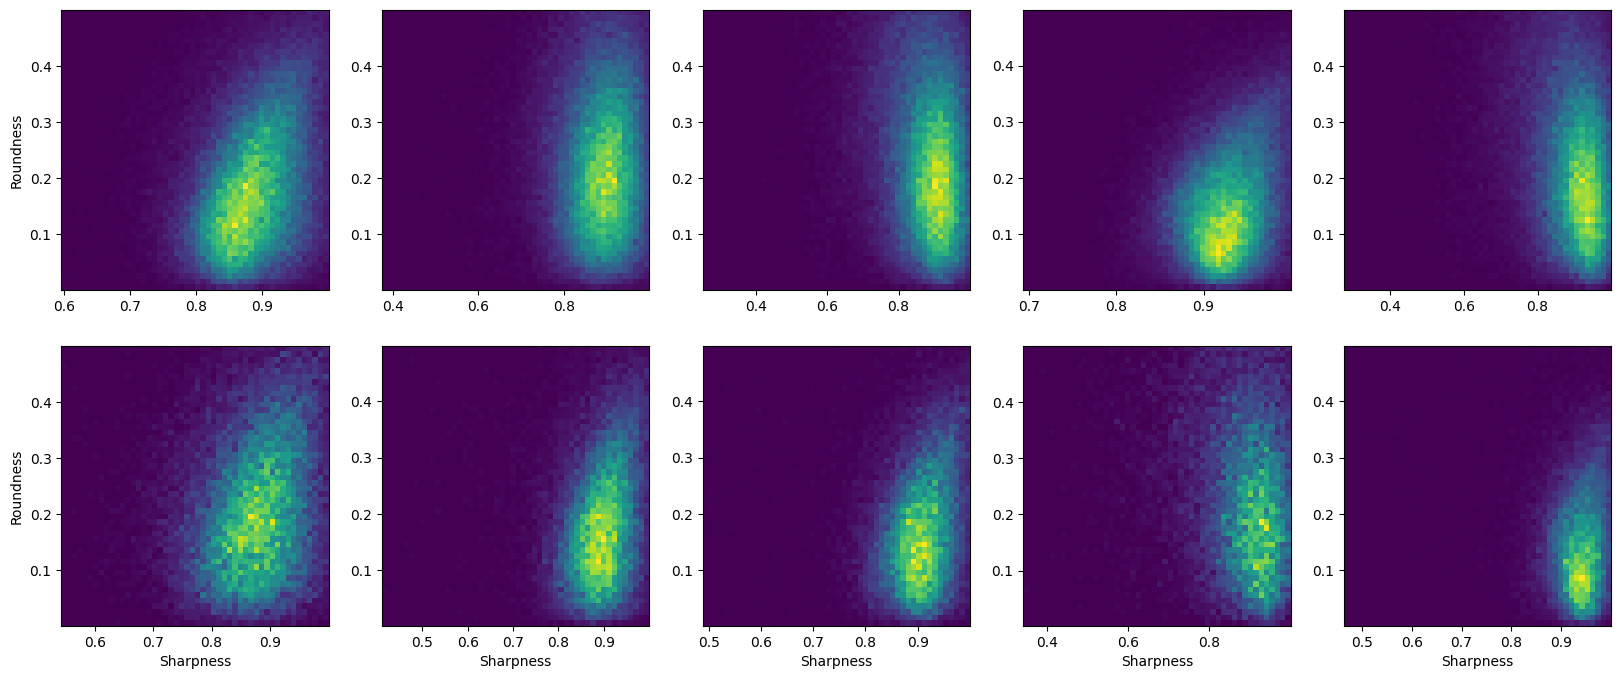

Found file for ngc1097 <class 'filter'> in /nexus/posix0/MIA-astro-env/eschinner/shared/PHANGS/JWST/v4p1/4793/release/ngc1097/images/
Searching in /nexus/posix0/MIA-astro-env/eschinner/shared/PHANGS/JWST/v4p1/4793/release/ngc1097/images/ for F150W data, with extension: *anchor*.fits
Files found: ['/nexus/posix0/MIA-astro-env/eschinner/shared/PHANGS/JWST/v4p1/4793/release/ngc1097/images/hlsp_4793_jwst_nircam_ngc1097_f150w_v4p1_anchor-atf150w.fits']
(6862, 6092)


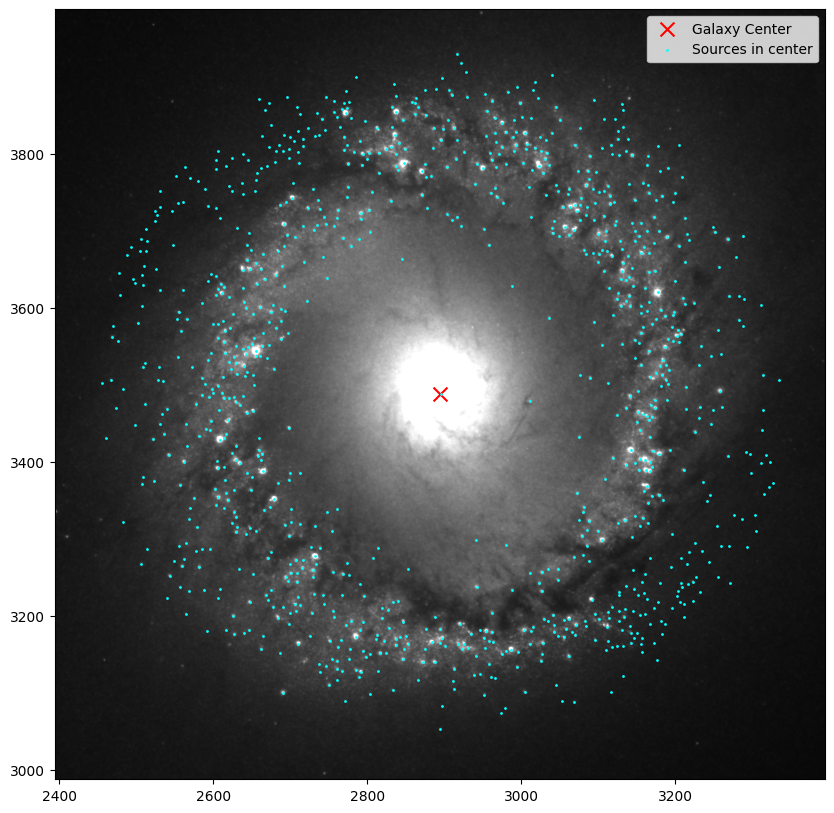

In [11]:
config_file = '/nexus/posix0/MIA-astro-env/eschinner/reho/centres/jwst_aperture_photometry/config/config.toml'     # Photometry parameters
local_file = '/nexus/posix0/MIA-astro-env/eschinner/reho/centres/jwst_aperture_photometry/config/local.toml'        # Paths to directories

def load_config(config_path: str) -> dict:
    with open(config_path, "rb") as f:
        return tomllib.load(f)


# Unpack the parameters from the config file
conf = load_config(config_file)
local = load_config(local_file)
gal = conf['targets'][0]
band = conf['bands'][0]
cat_dir = local['out_dir']
jwst_dir = local['jwst_dir']
version = conf['version']
projects = conf['projects']
targets = conf['targets']
ptype = conf['ptype']

catalog = load_catalogs(gal, band, cat_dir)

fig, ax = plt.subplots(2, 5, figsize=(20, 8))
axes = ax.flatten()
for i, band in enumerate(conf['bands']):
    catalog = load_catalogs(gal, band, cat_dir)
    x = catalog['sharpness']
    y = catalog['roundness']
    axes[i].hist2d(x, y, bins=50)
    axes[i].set_xlabel('Sharpness') if i >= 5 else None
    axes[i].set_ylabel('Roundness') if i % 5 == 0 else None
plt.show()

# Determine the path based on the
path = get_path_to_file(
     wdir=jwst_dir, 
     version=version, 
     project=projects[0], 
     galaxy=targets[0],
     ptype=ptype[0])

# Load the JWST image
band = conf['bands'][0]
catalog = load_catalogs(gal, band, cat_dir)
img, header = open_jwst(path, gal, local['jwst_dir'], band)
print(img.shape)
# Find the galaxy center
# x_gc, y_gc = find_galaxy_center(img, header)
x_gc, y_gc = 2894, 3488 # Placeholder values for the galaxy center
# Plot the image with the galaxy center marked
fig, ax = plt.subplots(figsize=(10, 10))

norm = ImageNormalize(img, interval=PercentileInterval(99.9))
ax.imshow(img, origin='lower', cmap='gray', norm=norm)
ax.scatter(x_gc, y_gc, s=100, color='red', marker='x', label='Galaxy Center')
sources_mask = sources_in_center(catalog, x_gc, y_gc, r=450)
ax.scatter(catalog['x_center'][sources_mask], catalog['y_center'][sources_mask], s=1, color='cyan', label='Sources in center')
ax.set_xlim(x_gc-500, x_gc+500)
ax.set_ylim(y_gc-500, y_gc+500)
ax.legend()
plt.show()

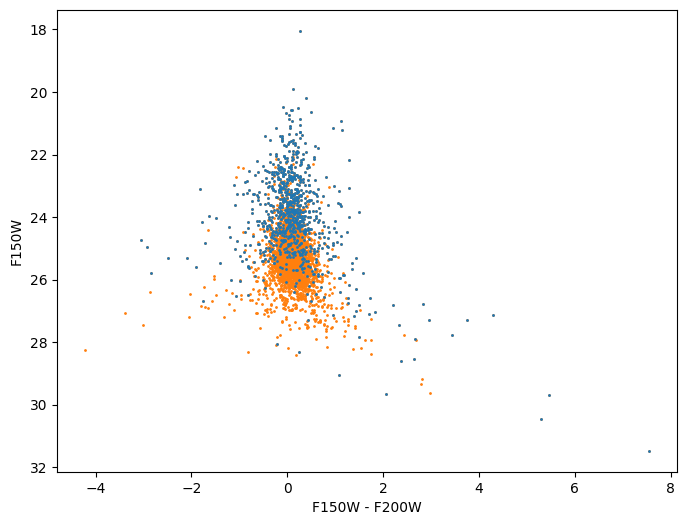

In [20]:
# Make a CMD using the catalog of sources in the center of the galaxy
fig, ax = plt.subplots(figsize=(8, 6))
make_cmd('f150w', 'f200w', gal, cat_dir, col='tab:orange', ax=ax, ext="", center=False)
make_cmd('f150w', 'f200w', gal, cat_dir, col='tab:blue', ax=ax, ext="", center=True)
ax.invert_yaxis()
plt.show()

['id_f150w', 'x_center_f150w', 'y_center_f150w', 'aperture_sum_f150w', 'flux_f150w', 'sharpness_f150w', 'roundness_f150w', 'finder_mag_f150w', 'peak_f150w', 'ra_f150w', 'dec_f150w', 'finder_flux_abmag_f150w', 'aperture_sum_abmag_f150w', 'id_f200w', 'x_center_f200w', 'y_center_f200w', 'aperture_sum_f200w', 'flux_f200w', 'sharpness_f200w', 'roundness_f200w', 'finder_mag_f200w', 'peak_f200w', 'ra_f200w', 'dec_f200w', 'finder_flux_abmag_f200w', 'aperture_sum_abmag_f200w']


KeyError: 'x_center'

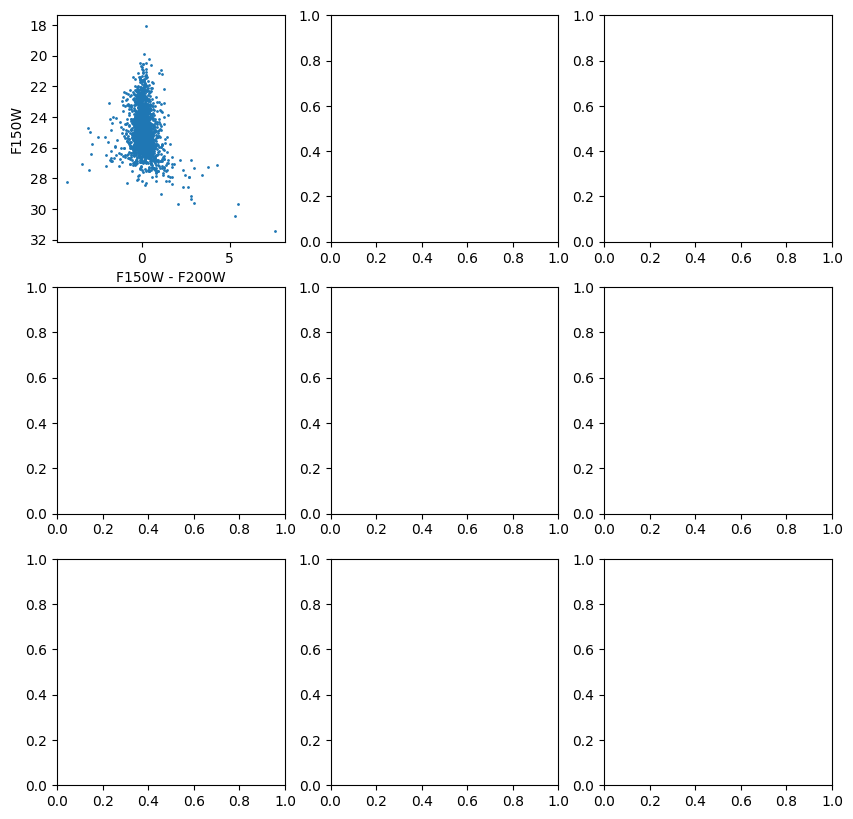

In [5]:

fig, ax = plt.subplots(3, 3, figsize=(10, 10))
make_cmd('f150w', 'f200w', gal, cat_dir, ax=ax[0, 0])
make_cmd('f150w', 'f277w', gal, cat_dir, ax=ax[0, 1])
make_cmd('f150w', 'f360m', gal, cat_dir, ax=ax[0, 2])
make_cmd('f200w', 'f277w', gal, cat_dir, ax=ax[1, 0])
make_cmd('f200w', 'f360m', gal, cat_dir, ax=ax[1, 1])
make_cmd('f277w', 'f360m', gal, cat_dir, ax=ax[1, 2])
make_cmd('f150w', 'f444w', gal, cat_dir, ax=ax[2, 0])
make_cmd('f200w', 'f444w', gal, cat_dir, ax=ax[2, 1])
make_cmd('f277w', 'f444w', gal, cat_dir, ax=ax[2, 2])
for i in range(3):
    for j in range(3):
        ax[i, j].set_xlim(-2, 4)
        ax[i, j].set_ylim(24, 16)
plt.tight_layout()
plt.show()

['id_f150w', 'x_center_f150w', 'y_center_f150w', 'aperture_sum_f150w', 'flux_f150w', 'sharpness_f150w', 'roundness_f150w', 'finder_mag_f150w', 'peak_f150w', 'ra_f150w', 'dec_f150w', 'finder_flux_abmag_f150w', 'aperture_sum_abmag_f150w', 'id_f164n', 'x_center_f164n', 'y_center_f164n', 'aperture_sum_f164n', 'flux_f164n', 'sharpness_f164n', 'roundness_f164n', 'finder_mag_f164n', 'peak_f164n', 'ra_f164n', 'dec_f164n', 'finder_flux_abmag_f164n', 'aperture_sum_abmag_f164n']


KeyError: 'x_center'

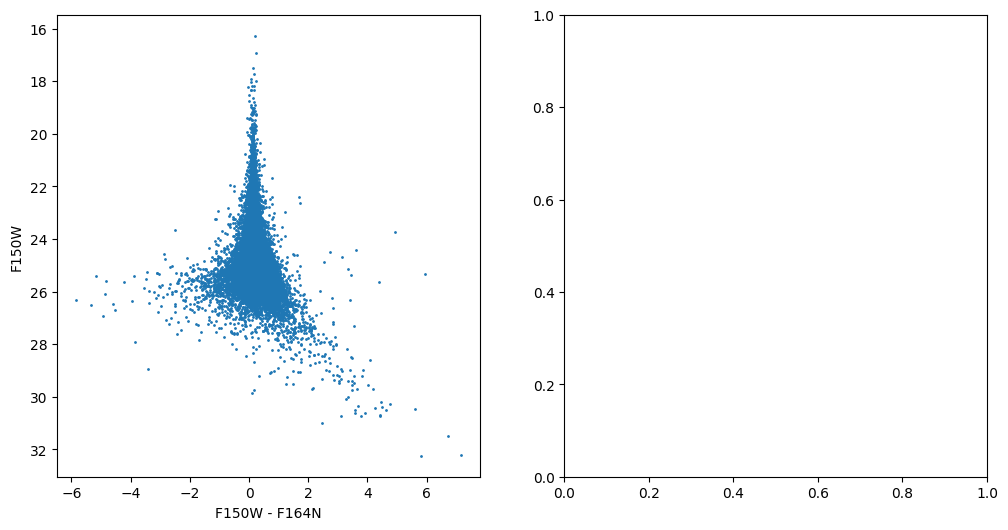

In [6]:
# Normal catalogs
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
make_cmd('f150w', 'f164n', gal, cat_dir, col='tab:blue', ax=ax[0], rms=False, contours=False)
make_cmd('f150w', 'f164n', gal, cat_dir, col='tab:orange', ax=ax[1], rms=True, contours=False)
ax[0].set_xlim(-3, 4)
ax[0].set_ylim(30, 18)
ax[1].set_xlim(-3, 4)
ax[1].set_ylim(30, 18)
ax[0].set_title('Fixed rms')
ax[1].set_title('Variable rms bkg')
plt.tight_layout()

In [7]:
# Alternative approach using standardised aperture corrections from the JWST CRDS.
path_to_crds = "/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/jwst_pipeline/crds_cache/jwst_ops/references/jwst/" + 'nircam' + "/"

# Get the apcorr file using glob
apcorr_files = glob.glob(path_to_crds + f"*apcorr*")
if len(apcorr_files) == 0:
    raise FileNotFoundError(f"No apcorr files found for {band} in {inst} at {path_to_crds}")
else:
    print(f"Found apcorr files: {apcorr_files}")

# Load the file
apcorr_data = fits.getdata(apcorr_files[0], ext=1)
print(f"APCORR data columns: {apcorr_data.columns.names}")

# Print all the unique filters in the apcorr file
print("Unique eefraction values:", np.unique(apcorr_data['eefraction']))

# Get data for a specific eefraction
# The eefraction is the fraction of the total flux that is enclosed within the aperture radius.
eefraction_value = 0.70
row = apcorr_data[apcorr_data['eefraction'] == eefraction_value]

# Limit to a specific filter 
row = row[(row['filter'] == band.upper())]

# Extract values
radius = row['radius'][0]   # in pixels
sky_in = row['skyin'][0]    # in pixels
sky_out = row['skyout'][0]  # in pixels
apcorr = row['apcorr'][0]   # factor to multiply enclosed flux to get total flux
print(f"Using aperture correction factor of {apcorr} for radius {radius} pixels and eefraction {eefraction_value}")

Found apcorr files: ['/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/jwst_pipeline/crds_cache/jwst_ops/references/jwst/nircam/jwst_nircam_apcorr_0004.fits', '/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/jwst_pipeline/crds_cache/jwst_ops/references/jwst/nircam/jwst_nircam_apcorr_0005.fits']
APCORR data columns: ['filter', 'pupil', 'eefraction', 'radius', 'apcorr', 'skyin', 'skyout']
Unique eefraction values: [0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.85 0.9 ]
Using aperture correction factor of 1.4485000371932983 for radius 3.1989998817443848 pixels and eefraction 0.7


In [11]:
# Get all the f150w catalogs 
f150w_catalogs = glob.glob(f"{cat_dir}*F150W*cat*.fits")
print(f"Found f150w catalogs: {f150w_catalogs} in {cat_dir}")

Found f150w catalogs: ['/nexus/posix0/MIA-astro-env/eschinner/reho/centres/jwst_aperture_photometry/catalogs/ngc1097_jwst_F150W_cat_snrmap.fits', '/nexus/posix0/MIA-astro-env/eschinner/reho/centres/jwst_aperture_photometry/catalogs/ngc1097_jwst_F150W_cat_rms.fits', '/nexus/posix0/MIA-astro-env/eschinner/reho/centres/jwst_aperture_photometry/catalogs/ngc1097_jwst_F150W_cat_box25.fits', '/nexus/posix0/MIA-astro-env/eschinner/reho/centres/jwst_aperture_photometry/catalogs/ngc1097_jwst_F150W_cat.fits'] in /nexus/posix0/MIA-astro-env/eschinner/reho/centres/jwst_aperture_photometry/catalogs/


['id_box25', 'x_center_box25', 'y_center_box25', 'aperture_sum_box25', 'flux_box25', 'sharpness_box25', 'roundness_box25', 'finder_mag_box25', 'peak_box25', 'ra_box25', 'dec_box25', 'finder_flux_abmag_box25', 'aperture_sum_abmag_box25', 'id_rms', 'x_center_rms', 'y_center_rms', 'aperture_sum_rms', 'flux_rms', 'sharpness_rms', 'roundness_rms', 'finder_mag_rms', 'peak_rms', 'ra_rms', 'dec_rms', 'finder_flux_abmag_rms', 'aperture_sum_abmag_rms']
50000 50000
47770
Number of sources in box25 not in matched: 2230
Number of sources in rms not in matched: 2230


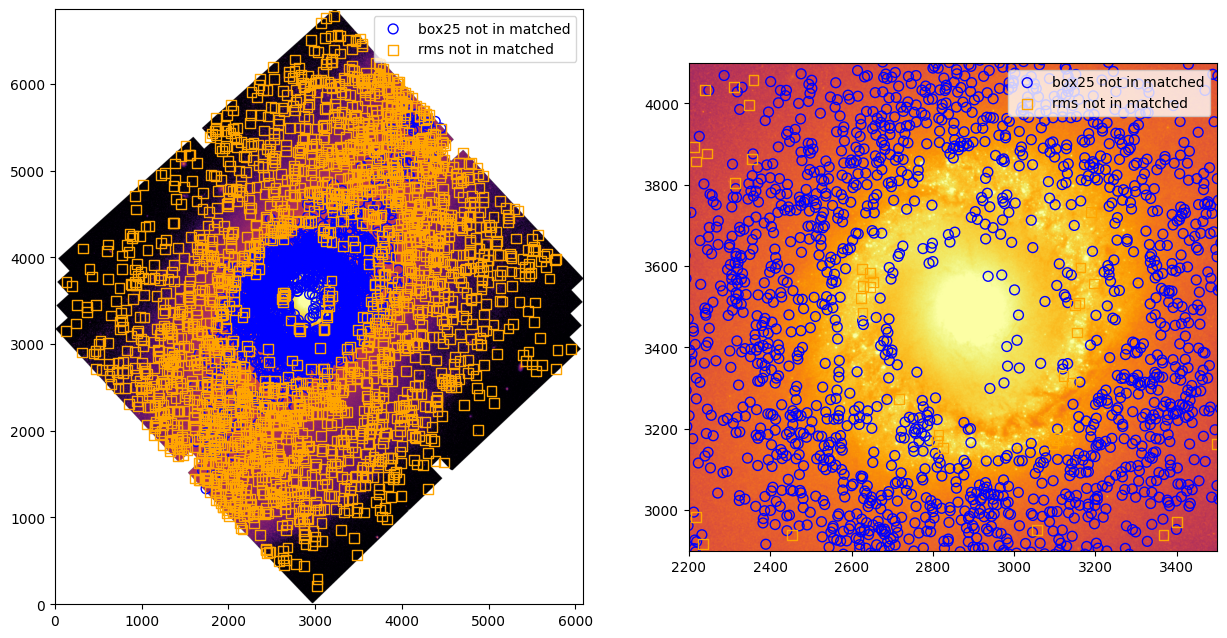

In [25]:
cat_box25 = Table.read(f"{cat_dir}{gal}_jwst_{band.upper()}_cat_box25.fits")
cat_box50 = Table.read(f"{cat_dir}{gal}_jwst_{band.upper()}_cat_rms.fits")

# Match the two catalogs
matched_cat = match(cat_box25, cat_box50, npix=2, keys=['box25', 'rms'])
print(matched_cat.colnames)
print(len(cat_box25), len(cat_box50))
print(len(matched_cat))

#
cat_box25_notin_matched = cat_box25[~np.isin(cat_box25['id'], matched_cat['id_box25'])]
cat_rms_notin_matched = cat_box50[~np.isin(cat_box50['id'], matched_cat['id_rms'])]
print(f"Number of sources in box25 not in matched: {len(cat_box25_notin_matched)}")
print(f"Number of sources in rms not in matched: {len(cat_rms_notin_matched)}")

# Plot the sources not in the matched catalog
# And the mosaic with these sources highlighted
from astropy.visualization import ImageNormalize, LogStretch
fig, ax = plt.subplots(1,2, figsize=(15, 8))
norm_mosaic = ImageNormalize(vmin=np.nanpercentile(img, 25.00), 
                            vmax=np.nanpercentile(img, 99.9),
                            stretch=LogStretch())
ax[0].imshow(img, origin='lower', cmap='inferno', norm=norm_mosaic)
ax[1].imshow(img, origin='lower', cmap='inferno', norm=norm_mosaic)
ax[1].set_xlim(2200, 3500)
ax[1].set_ylim(2900, 4100)
ax[0].scatter(cat_box25_notin_matched['x_center'], cat_box25_notin_matched['y_center'], s=50, edgecolor='blue', facecolor='none', marker='o', label='box25 not in matched')
ax[0].scatter(cat_rms_notin_matched['x_center'], cat_rms_notin_matched['y_center'], s=50, edgecolor='orange', facecolor='none', marker='s', label='rms not in matched')
ax[1].scatter(cat_box25_notin_matched['x_center'], cat_box25_notin_matched['y_center'], s=50, edgecolor='blue', facecolor='none', marker='o', label='box25 not in matched')
ax[1].scatter(cat_rms_notin_matched['x_center'], cat_rms_notin_matched['y_center'], s=50, edgecolor='orange', facecolor='none', marker='s', label='rms not in matched')
ax[0].legend()
ax[1].legend(loc='upper right')
plt.show()